In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pyreadstat
from sklearn.mixture import GaussianMixture


### Ucitavanje podataka i pravljenje dataframe-ova 

In [2]:
idn_df, meta = pyreadstat.read_sav('data/IDN.sav')
df_fila = pd.read_csv('data/fila_baza.csv')

#### Listanje broja redova i kolona

In [3]:
idn_df.shape

(1212, 53)

In [4]:
df_fila.shape

(133, 26)

#### Pregled dataframe-ova

In [5]:
idn_df.head()

,Pol,Godine,Sa_kim_zivi,Uspeh,AKT_VI,AKT_KOMUNIKACIJA_INTERNET,AKT_DRUSTVENIPROFILI_DRUGI,AKT_DRUSTVENIPROFIL_SVOJ,AKT_KREATIVNO,MOTIV_YCI,...,BFI_N,BFI_A,BFI_C,BFI_O,ZBFI_E,ZBFI_N,ZBFI_A,ZBFI_C,ZBFI_O,Membership
0,1.0,23.0,"otac, majka, brat ili sestra (ili više njih)",5.0,3.5,4.333333,4.0,3.000000,1.0,3.666667,...,1.50,4.00,2.75,5.00,-0.811704,-1.321752,0.514212,-0.561367,1.678568,1.0
1,1.0,18.0,otac,6.0,1.0,2.666667,1.8,1.333333,3.0,2.000000,...,2.75,2.50,4.50,1.75,-1.079253,0.049365,-1.335424,1.338316,-2.516652,4.0
2,1.0,20.0,"otac, majka, brat ili sestra (ili više njih)",6.0,3.5,4.500000,2.4,1.666667,2.0,2.833333,...,4.75,3.75,2.00,5.00,-0.276607,2.243152,0.205939,-1.375516,1.678568,7.0
3,1.0,20.0,"otac, majka, brat ili sestra (ili više njih)",4.0,1.0,3.666667,3.0,2.666667,2.0,5.000000,...,2.50,3.50,4.00,2.75,-0.009058,-0.224859,-0.102333,0.795550,-1.225815,1.0
4,1.0,23.0,brat ili sestra (ili više njih),4.0,1.5,3.833333,3.4,2.666667,1.0,4.000000,...,3.00,4.75,2.00,4.50,-0.811704,0.323588,1.439030,-1.375516,1.033149,2.0


In [6]:
df_fila.head()

,ispit,crosscul,egy_fe_fam_ll,egy_fe_fam_OR,egy_fe_fam_RR,egy_fe_unfam_LL,egy_fe_unfam_OR,egy_fe_unfam_RR,egy_m_fam_ll,egy_m_fam_OR,...,srb_fe_fam_RR,srb_fe_unfam_LL,srb_fe_unfam_OR,srb_fe_unfam_RR,srb_m_fam_LL,srb_m_fam_OR,srb_m_fam_RR,srb_m_unfam_LL,srb_m_unfam_OR,srb_m_unfam_RR
0,1,egy,2.500000,3.833333,2.666667,3.500000,2.833333,2.333333,2.833333,2.166667,...,2.166667,3.500000,3.500000,2.833333,3.166667,2.833333,3.500000,2.166667,2.666667,3.000000
1,2,egy,4.000000,4.000000,4.500000,3.666667,3.833333,4.000000,3.500000,3.666667,...,3.833333,4.166667,3.833333,4.166667,3.833333,4.000000,3.833333,3.666667,4.500000,3.666667
2,3,egy,3.666667,3.833333,3.333333,3.833333,3.500000,3.666667,3.666667,3.166667,...,3.666667,4.500000,3.500000,3.500000,4.666667,2.666667,3.666667,3.666667,3.333333,3.666667
3,4,egy,3.333333,3.333333,3.666667,4.500000,4.333333,3.666667,3.500000,3.500000,...,3.666667,3.833333,4.000000,3.833333,3.500000,3.333333,3.166667,3.333333,3.833333,3.166667
4,5,egy,3.833333,3.833333,3.666667,3.333333,4.666667,3.500000,3.333333,3.666667,...,3.666667,3.500000,4.666667,3.666667,3.333333,3.166667,3.333333,3.333333,3.333333,3.500000


#### Statistika po kolonama

In [7]:
idn_df.describe()

,Pol,Godine,Uspeh,AKT_VI,AKT_KOMUNIKACIJA_INTERNET,AKT_DRUSTVENIPROFILI_DRUGI,AKT_DRUSTVENIPROFIL_SVOJ,AKT_KREATIVNO,MOTIV_YCI,MOTIV_E,...,BFI_N,BFI_A,BFI_C,BFI_O,ZBFI_E,ZBFI_N,ZBFI_A,ZBFI_C,ZBFI_O,Membership
count,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,...,1211.000000,1211.000000,1211.000000,1211.000000,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1212.000000
mean,1.570132,17.860561,4.366337,2.497937,3.924367,2.942904,2.117162,1.400715,3.243674,4.000165,...,2.704996,3.582989,3.267135,3.699628,-8.179162e-15,2.839824e-15,1.804227e-15,-1.279094e-15,-5.180919e-15,3.827558
std,0.524415,2.639883,1.024613,1.127776,0.522202,0.958860,0.855259,0.661796,0.961590,0.732382,...,0.911666,0.810971,0.921207,0.774691,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.520430
min,1.000000,14.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.250000,1.000000,1.000000,-2.684546e+00,-1.870199e+00,-2.876787e+00,-2.461049e+00,-3.484780e+00,1.000000
25%,1.000000,16.000000,4.000000,1.500000,3.666667,2.200000,1.333333,1.000000,2.666667,3.600000,...,2.000000,3.000000,2.750000,3.125000,-5.441557e-01,-7.733054e-01,-7.188785e-01,-5.613666e-01,-7.417515e-01,1.000000
50%,2.000000,17.000000,4.000000,2.500000,4.000000,3.000000,2.000000,1.000000,3.333333,4.000000,...,2.750000,3.500000,3.250000,3.750000,-9.058215e-03,4.936473e-02,-1.023333e-01,-1.860017e-02,6.502151e-02,4.000000
75%,2.000000,20.000000,5.000000,3.500000,4.333333,3.600000,2.666667,1.666667,4.000000,4.600000,...,3.250000,4.250000,4.000000,4.250000,7.935880e-01,5.978115e-01,8.224846e-01,7.955495e-01,7.104399e-01,6.000000
max,3.000000,31.000000,7.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,1.596234e+00,2.517375e+00,1.747302e+00,1.881082e+00,1.678568e+00,7.000000


In [8]:
df_fila.describe()

,ispit,egy_fe_fam_ll,egy_fe_fam_OR,egy_fe_fam_RR,egy_fe_unfam_LL,egy_fe_unfam_OR,egy_fe_unfam_RR,egy_m_fam_ll,egy_m_fam_OR,egy_m_fam_RR,...,srb_fe_fam_RR,srb_fe_unfam_LL,srb_fe_unfam_OR,srb_fe_unfam_RR,srb_m_fam_LL,srb_m_fam_OR,srb_m_fam_RR,srb_m_unfam_LL,srb_m_unfam_OR,srb_m_unfam_RR
count,133.00000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,...,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000
mean,67.00000,2.709273,2.533835,2.515038,2.562657,3.177945,3.289474,2.778195,2.823308,2.520050,...,2.487469,2.426065,2.464912,2.659148,2.849624,2.962406,2.706767,2.652882,2.343358,2.413534
std,38.53786,0.865698,0.963072,0.985257,0.970222,0.782327,0.773317,0.874903,0.789706,0.904543,...,0.899547,1.012633,1.008185,0.859162,0.840841,0.779476,0.836396,0.823437,0.979323,1.038728
min,1.00000,1.000000,1.000000,1.000000,1.000000,1.166667,1.166667,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,34.00000,2.166667,1.833333,1.666667,1.666667,2.666667,2.833333,2.166667,2.333333,1.666667,...,1.666667,1.500000,1.666667,2.000000,2.166667,2.500000,2.000000,2.000000,1.500000,1.500000
50%,67.00000,2.833333,2.500000,2.333333,2.500000,3.333333,3.500000,2.833333,3.000000,2.500000,...,2.500000,2.333333,2.500000,2.666667,3.000000,3.166667,2.833333,2.833333,2.166667,2.166667
75%,100.00000,3.333333,3.333333,3.333333,3.333333,3.666667,3.833333,3.500000,3.333333,3.333333,...,3.166667,3.333333,3.333333,3.333333,3.333333,3.500000,3.333333,3.333333,3.000000,3.333333
max,133.00000,4.500000,4.833333,4.666667,4.500000,4.666667,5.000000,4.500000,4.333333,4.500000,...,5.000000,4.500000,4.666667,4.666667,4.666667,4.333333,4.500000,4.333333,4.500000,4.333333


#### Pregled tipova kolona

In [9]:
idn_df.dtypes

Pol                            float64
Godine                         float64
Sa_kim_zivi                     object
Uspeh                          float64
AKT_VI                         float64
AKT_KOMUNIKACIJA_INTERNET      float64
AKT_DRUSTVENIPROFILI_DRUGI     float64
AKT_DRUSTVENIPROFIL_SVOJ       float64
AKT_KREATIVNO                  float64
MOTIV_YCI                      float64
MOTIV_E                        float64
MOTIV_IF                       float64
MOTIV_HS                       float64
MOTIV_C                        float64
SADRZ_OBRAZ                    float64
SADRZ_UMETN                    float64
SADRZ_ULF                      float64
SADRZ_IZGLED                   float64
SADRZ_SPORT                    float64
SADRZ_DRUSTVTEME               float64
SADRZ_RELFIL                   float64
SADRZ_NAUKA                    float64
SADRZ_NASILJE                  float64
ZAKT_VI                        float64
ZAKT_KOMUNIKACIJA_INTERNET     float64
ZAKT_DRUSTVENIPROFILI_DRU

In [10]:
df_fila.dtypes

ispit                int64
crosscul            object
egy_fe_fam_ll      float64
egy_fe_fam_OR      float64
egy_fe_fam_RR      float64
egy_fe_unfam_LL    float64
egy_fe_unfam_OR    float64
egy_fe_unfam_RR    float64
egy_m_fam_ll       float64
egy_m_fam_OR       float64
egy_m_fam_RR       float64
egy_m_unfam_LL     float64
egy_m_unfam_OR     float64
egy_m_unfam_RR     float64
srb_fe_fam_LL      float64
srb_fe_fam_OR      float64
srb_fe_fam_RR      float64
srb_fe_unfam_LL    float64
srb_fe_unfam_OR    float64
srb_fe_unfam_RR    float64
srb_m_fam_LL       float64
srb_m_fam_OR       float64
srb_m_fam_RR       float64
srb_m_unfam_LL     float64
srb_m_unfam_OR     float64
srb_m_unfam_RR     float64
dtype: object

#### Primer pregleda klasifikacionih kolona 

/tmp/ipykernel_13240/2382139740.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


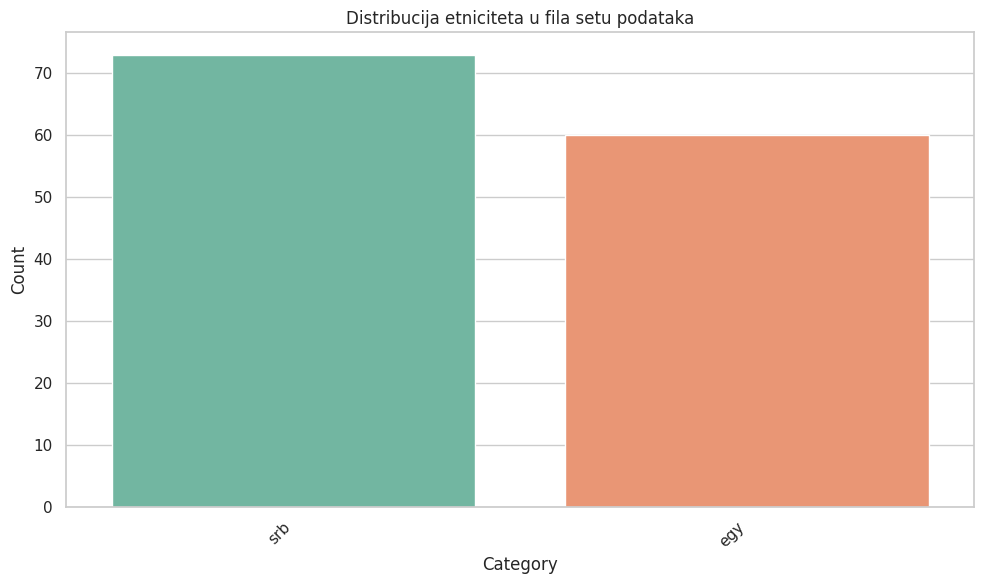

In [11]:
# Set Seaborn style
sns.set(style="whitegrid")

# Count category occurrences
category_counts = df_fila['crosscul'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

# Create barplot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=category_counts,
    x='Category',
    y='Count',
    palette='Set2' 
)

plt.title('Distribucija etniciteta u fila setu podataka')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

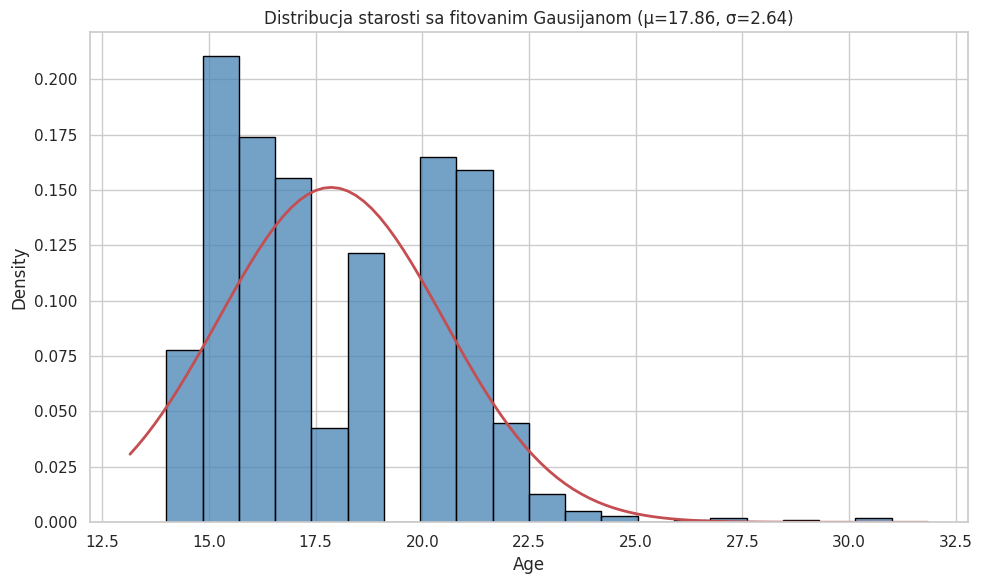

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Drop NaNs if any
ages = idn_df['Godine'].dropna()

# Fit a normal distribution to the data
mu, std = norm.fit(ages)

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(ages, bins=20, kde=False, stat='density', color='steelblue', edgecolor='black')

# Plot the fitted Gaussian
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r', linewidth=2)

plt.title(f'Distribucja starosti sa fitovanim Gausijanom (μ={mu:.2f}, σ={std:.2f})')
plt.xlabel('Age')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

#### Provera praznih redova u svakom dataframe-u

In [13]:
for name, df in {'df_fila': df_fila, 'idn_df': idn_df}.items():
    print(f"\nNulls in {name}:")
    print(df.isnull().sum())
    print("Total null values:", df.isnull().sum().sum())


Nulls in df_fila:
ispit              0
crosscul           0
egy_fe_fam_ll      0
egy_fe_fam_OR      0
egy_fe_fam_RR      0
egy_fe_unfam_LL    0
egy_fe_unfam_OR    0
egy_fe_unfam_RR    0
egy_m_fam_ll       0
egy_m_fam_OR       0
egy_m_fam_RR       0
egy_m_unfam_LL     0
egy_m_unfam_OR     0
egy_m_unfam_RR     0
srb_fe_fam_LL      0
srb_fe_fam_OR      0
srb_fe_fam_RR      0
srb_fe_unfam_LL    0
srb_fe_unfam_OR    0
srb_fe_unfam_RR    0
srb_m_fam_LL       0
srb_m_fam_OR       0
srb_m_fam_RR       0
srb_m_unfam_LL     0
srb_m_unfam_OR     0
srb_m_unfam_RR     0
dtype: int64
Total null values: 0

Nulls in idn_df:
Pol                            0
Godine                         0
Sa_kim_zivi                    0
Uspeh                          0
AKT_VI                         0
AKT_KOMUNIKACIJA_INTERNET      0
AKT_DRUSTVENIPROFILI_DRUGI     0
AKT_DRUSTVENIPROFIL_SVOJ       0
AKT_KREATIVNO                  0
MOTIV_YCI                      0
MOTIV_E                        0
MOTIV_IF            

#### idn_df sadrzi prazne redove, stoga mora da se proveri i eventualno popuni ili izbaci

In [14]:
null_rows = idn_df[idn_df.isnull().any(axis=1)]
print(null_rows)


     Pol  Godine        Sa_kim_zivi  Uspeh  AKT_VI  AKT_KOMUNIKACIJA_INTERNET  \
329  1.0    16.0  majka,otac,sestra    5.0     3.0                   3.666667   

     AKT_DRUSTVENIPROFILI_DRUGI  AKT_DRUSTVENIPROFIL_SVOJ  AKT_KREATIVNO  \
329                         2.8                       2.0            1.0   

     MOTIV_YCI  ...  BFI_N  BFI_A  BFI_C  BFI_O  ZBFI_E  ZBFI_N  ZBFI_A  \
329   2.833333  ...    NaN    NaN    NaN    NaN     NaN     NaN     NaN   

     ZBFI_C  ZBFI_O  Membership  
329     NaN     NaN         7.0  

[1 rows x 53 columns]


##### Jedan red ima prazne vrednosti za sledece kolone:
##### BFI_E, BFI_N, BFI_A, BFI_C, BFI_O, ZBFI_E, ZBFI_N, ZBFI_A, ZBFI_C, ZBFI_O                         

### LPA ANALIZA na idn_df dataframe-u 

In [15]:
idn_df.columns

Index(['Pol', 'Godine', 'Sa_kim_zivi', 'Uspeh', 'AKT_VI',
       'AKT_KOMUNIKACIJA_INTERNET', 'AKT_DRUSTVENIPROFILI_DRUGI',
       'AKT_DRUSTVENIPROFIL_SVOJ', 'AKT_KREATIVNO', 'MOTIV_YCI', 'MOTIV_E',
       'MOTIV_IF', 'MOTIV_HS', 'MOTIV_C', 'SADRZ_OBRAZ', 'SADRZ_UMETN',
       'SADRZ_ULF', 'SADRZ_IZGLED', 'SADRZ_SPORT', 'SADRZ_DRUSTVTEME',
       'SADRZ_RELFIL', 'SADRZ_NAUKA', 'SADRZ_NASILJE', 'ZAKT_VI',
       'ZAKT_KOMUNIKACIJA_INTERNET', 'ZAKT_DRUSTVENIPROFILI_DRUGI',
       'ZAKT_DRUSTVENIPROFIL_SVOJ', 'ZAKT_KREATIVNO', 'ZMOTIV_YCI', 'ZMOTIV_E',
       'ZMOTIV_IF', 'ZMOTIV_HS', 'ZMOTIV_C', 'ZSADRZ_OBRAZ', 'ZSADRZ_UMETN',
       'ZSADRZ_ULF', 'ZSADRZ_IZGLED', 'ZSADRZ_SPORT', 'ZSADRZ_DRUSTVTEME',
       'ZSADRZ_RELFIL', 'ZSADRZ_NAUKA', 'ZSADRZ_NASILJE', 'BFI_E', 'BFI_N',
       'BFI_A', 'BFI_C', 'BFI_O', 'ZBFI_E', 'ZBFI_N', 'ZBFI_A', 'ZBFI_C',
       'ZBFI_O', 'Membership'],
      dtype='object')

#### 1: Odabir i priprema podataka
#####  Prvo bi trebalo da odabereš kolone koje želiš da koristiš za LPA. 
#####  Poželjno je da koristiš Z-vrednosti (standardizovane vrednosti), jer omogućavaju uporedivost između mera.

In [16]:
z_columns = ['ZAKT_VI',
       'ZAKT_KOMUNIKACIJA_INTERNET', 'ZAKT_DRUSTVENIPROFILI_DRUGI',
       'ZAKT_DRUSTVENIPROFIL_SVOJ', 'ZAKT_KREATIVNO', 'ZMOTIV_YCI', 'ZMOTIV_E',
       'ZMOTIV_IF', 'ZMOTIV_HS', 'ZMOTIV_C', 'ZSADRZ_OBRAZ', 'ZSADRZ_UMETN',
       'ZSADRZ_ULF', 'ZSADRZ_IZGLED', 'ZSADRZ_SPORT', 'ZSADRZ_DRUSTVTEME',
       'ZSADRZ_RELFIL', 'ZSADRZ_NAUKA', 'ZSADRZ_NASILJE']
X = idn_df[z_columns].dropna()

#### 2: Treniranje Gaussian Mixture modela za više profila (klasa)
##### Ovaj model pokušava da pronađe "skrivene grupe" (profile) tako što pretpostavlja da podaci potiču iz više normalnih raspodela.

In [17]:
bic_scores = []
models = []

# Isprobavanje modela sa 2 do 6 profila
for k in range(2, 7):  
    model = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    model.fit(X)
    bic_scores.append(model.bic(X)) # BIC: kriterijum za izbor najboljeg modela
    models.append(model)

# Pronalaženje najboljeg broja profila (najniži BIC)
best_k = np.argmin(bic_scores) + 2
best_model = models[best_k - 2]

print(f"Optimalan broj profila: {best_k}")

Optimalan broj profila: 5


#### 3: Dodela profila svakom učesniku
##### Kada nađeš najbolji model, možeš svakom redu (osobi) da dodeliš profil kome pripada.

In [18]:
idn_df.loc[X.index, 'LPA_Profile'] = best_model.predict(X)


#### 4: Korelacija sa BFI osobinama ličnosti
##### Kada imaš dodeljene profile, možeš da analiziraš kako su povezani sa osobinama ličnosti iz BFI upitnika. Poželjno je da i ovde koristiš Z-vrednosti ako su dostupne.

In [19]:
bfi_columns = ['ZBFI_E', 'ZBFI_N', 'ZBFI_A', 'ZBFI_C', 'ZBFI_O']

# Opciono: koristi samo redove koji nemaju nedostajuće vrednosti u BFI i LPA varijablama.
corr_df = idn_df.loc[X.index, bfi_columns + z_columns]
correlation_matrix = corr_df.corr().loc[bfi_columns, z_columns]

#### 5: Vizualizacija korelacije (npr. heatmap)
##### Da bi lakše video odnose između varijabli, možeš napraviti vizuelni prikaz korelacija.

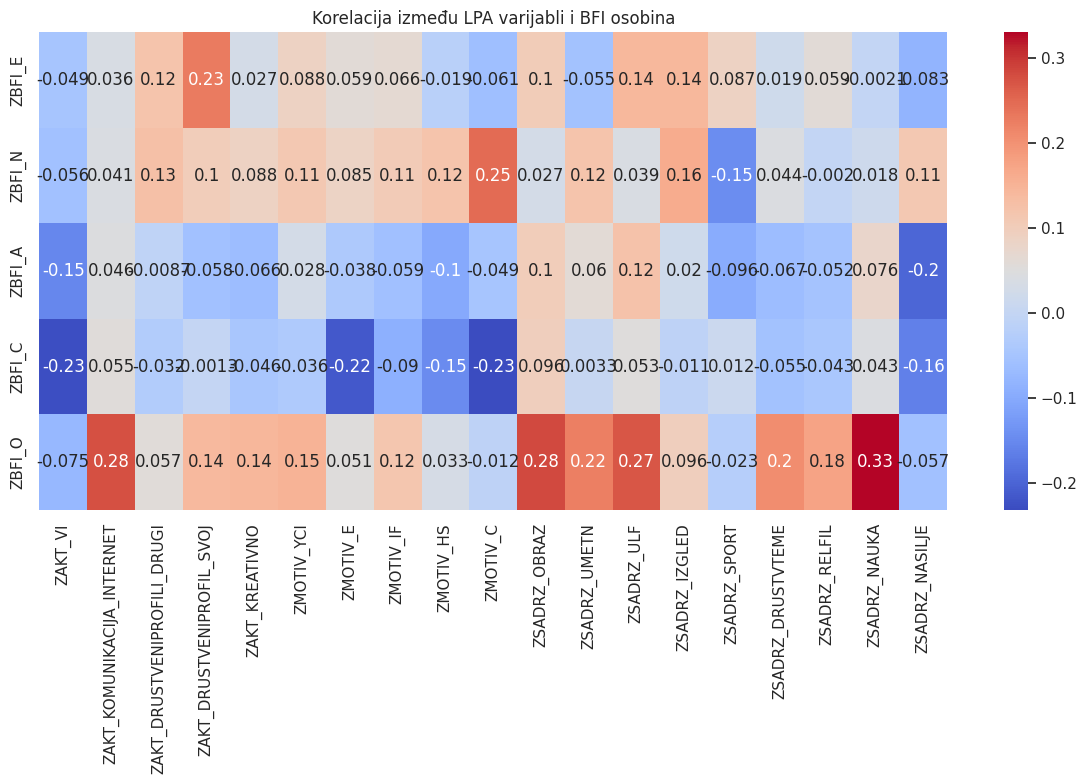

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Korelacija između LPA varijabli i BFI osobina')
plt.tight_layout()
plt.show()